In [1]:
import xarray as xr
import xscen as xs
from xscen import CONFIG
import xclim as xc
import glob
import figanos.matplotlib as fg
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt
xs.load_config("../config/config_general.yml", "../config/config_region.yml", "../config/paths.yml")

/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/esmf/8.8.0/lib/python3.11/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# Verify that issue #8 is fixed

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:108: UserWarning: CFTimeIndex converted to pandas DatetimeIndex with a 'standard' calendar.


<Axes: title={'left': 'Annual number of days with daily precipitation\nunder 1 mm/d.'}, xlabel='Time', ylabel='Number of dry days (days)'>

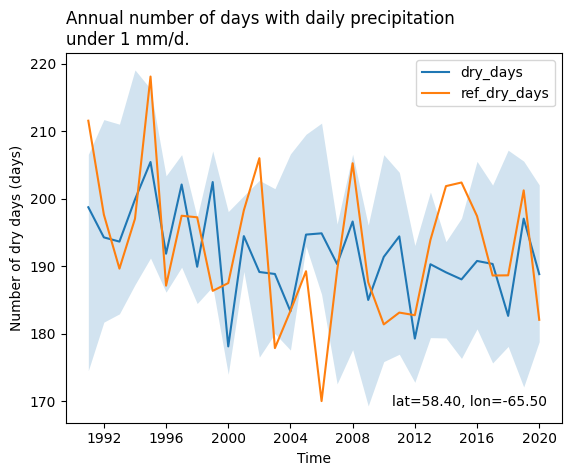

In [21]:
das=[]
for f in glob.glob(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/ssp245/*/day/pr/*"):
    ds= xr.open_zarr(f)
    ds=ds.sel(time=slice('1991','2020'))
    da=xc.atmos.dry_days(ds.pr, thresh='1 mm/d').to_dataset(name='dry_days')
    da= xs.spatial_mean(da, method='xesmf', spatial_subset=True, kwargs=dict(skipna=True),
                        region=dict(name='b', method='bbox',lon_bnds= [ -67, -64 ],lat_bnds= [ 56.35, 60.45 ]))
    das.append(da)
ens_stats = xs.ensemble_stats(
    datasets=das,
    statistics={
        "ensemble_percentiles": {"split": False}
    }, 
    common_attrs_only=True,
)
ax=fg.timeseries(ens_stats)

# ref
ds_ref=xr.open_zarr(f"{CONFIG['paths']['final']}/reference/QC-E5L_default.zarr.zip")
ds_ref=ds_ref.sel(time=slice('1991','2020'))
ds_ref=xc.atmos.dry_days(ds_ref.pr, thresh='1 mm/d').to_dataset(name='dry_days')

ds_ref= xs.spatial_mean(ds_ref, method='xesmf', spatial_subset=True,kwargs=dict(skipna=True),
                        region=dict(name='b', method='bbox',lon_bnds= [ -67, -64 ],lat_bnds= [ 56.35, 60.45 ]))
fg.timeseries({'ref':ds_ref},ax=ax)
# looks good
# TODO: test with casr when we do it.

/tmp/ipykernel_2185775/1318906239.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


2025-09-26 11:08:45 INFO     xscen.spatial   Loading longitude for more efficient subsetting.
2025-09-26 11:08:45 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/frontend.py:95: UserWarning: Variables {'rlon_bounds', 'rlat_bounds'} not found in object but are referred to in the CF attributes.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'rlon_bounds', 'rlat_bounds'} not found in object but are referred to in the CF attributes.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will

2025-09-26 11:08:51 INFO     xscen.spatial   Loading longitude for more efficient subsetting.
2025-09-26 11:08:51 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/frontend.py:95: UserWarning: Variables {'rlon_bounds', 'rlat_bounds'} not found in object but are referred to in the CF attributes.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'rlon_bounds', 'rlat_bounds'} not found in object but are referred to in the CF attributes.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will

...

2025-09-26 11:08:53 INFO     xscen.spatial   Loading longitude for more efficient subsetting.
2025-09-26 11:08:53 INFO     xscen.spatial   Loading latitude for more efficient subsetting.
2025-09-26 11:08:53 INFO     xscen.ensembles Calculating ensemble_percentiles from an ensemble of 4 simulations.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/frontend.py:95: UserWarning: Variables {'rlon_bounds', 'rlat_bounds'} not found in object but are referred to in the CF attributes.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'rlon_bounds', 'rlat_bounds'} not found in object but are referred to in the CF attributes.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will

2025-09-26 11:09:15 INFO     xscen.spatial   Loading longitude for more efficient subsetting.
2025-09-26 11:09:15 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/frontend.py:95: UserWarning: Variables {'rlon_bounds', 'rlat_bounds'} not found in object but are referred to in the CF attributes.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'rlon_bounds', 'rlat_bounds'} not found in object but are referred to in the CF attributes.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will

<Axes: title={'left': 'Annual number of days with daily precipitation\nunder 1 mm/d.'}, xlabel='Time', ylabel='Number of dry days (days)'>

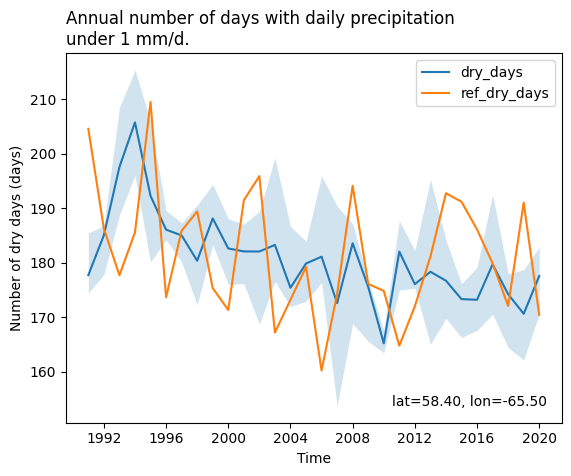

In [11]:
das=[]
for f in glob.glob(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO6e_v20/CMIP6/ScenarioMIP/NAM-C3/*/*/ssp585/*/day/pr/*"):
    ds= xr.open_zarr(f)
    ds=ds.sel(time=slice('1991','2020'))
    da=xc.atmos.dry_days(ds.pr, thresh='1 mm/d').to_dataset(name='dry_days')
    da= xs.spatial_mean(da, method='xesmf', spatial_subset=True, kwargs=dict(skipna=True),
                        region=dict(name='b', method='bbox',lon_bnds= [ -67, -64 ],lat_bnds= [ 56.35, 60.45 ]))
    das.append(da)
ens_stats = xs.ensemble_stats(
    datasets=das,
    statistics={
        "ensemble_percentiles": {"split": False}
    }, 
    common_attrs_only=True,
)
ax=fg.timeseries(ens_stats)

# ref
ds_ref=xr.open_zarr(f"{CONFIG['paths']['final']}/reference/NAM-C3_default.zarr.zip")
ds_ref=ds_ref.sel(time=slice('1991','2020'))
ds_ref=xc.atmos.dry_days(ds_ref.pr, thresh='1 mm/d').to_dataset(name='dry_days')

ds_ref= xs.spatial_mean(ds_ref, method='xesmf', spatial_subset=True,kwargs=dict(skipna=True),
                        region=dict(name='b', method='bbox',lon_bnds= [ -67, -64 ],lat_bnds= [ 56.35, 60.45 ]))
fg.timeseries({'ref':ds_ref},ax=ax)
# looks good


In [ ]:
das=[]
for f in glob.glob(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO6e-v20/CMIP6/ScenarioMIP/NAM-C3/*/*/ssp245/*/day/pr/*"):
    ds= xr.open_zarr(f)
    ds=ds.sel(time=slice('1991','2020'))
    da=xc.atmos.dry_days(ds.pr, thresh='1 mm/d').to_dataset(name='dry_days')
    da= xs.spatial_mean(da, method='xesmf', spatial_subset=True, kwargs=dict(skipna=True),
                        region=dict(name='b', method='bbox',lon_bnds= [ -67, -64 ],lat_bnds= [ 56.35, 60.45 ]))
    das.append(da)
ens_stats = xs.ensemble_stats(
    datasets=das,
    statistics={
        "ensemble_percentiles": {"split": False}
    }, 
    common_attrs_only=True,
)
ax=fg.timeseries(ens_stats)

# ref
ds_ref=xr.open_zarr(f"{CONFIG['paths']['final']}/reference/NAM-C3_default.zarr.zip")
ds_ref=ds_ref.sel(time=slice('1991','2020'))
ds_ref=xc.atmos.dry_days(ds_ref.pr, thresh='1 mm/d').to_dataset(name='dry_days')

ds_ref= xs.spatial_mean(ds_ref, method='xesmf', spatial_subset=True,kwargs=dict(skipna=True),
                        region=dict(name='b', method='bbox',lon_bnds= [ -67, -64 ],lat_bnds= [ 56.35, 60.45 ]))
fg.timeseries({'ref':ds_ref},ax=ax)
# looks good
# TODO: test with casr when we do it.

# Problem at the south of the v1.0 domain

/tmp/ipykernel_1460295/2020355077.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


2025-09-26 14:22:06 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/ESPO6e/coords/coords_southC3_235x700.nc.


/tmp/ipykernel_1460295/2020355077.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
/tmp/ipykernel_1460295/2020355077.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


2025-09-26 14:22:35 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/ESPO6e/coords/coords_middleC3_267x700.nc.


/tmp/ipykernel_1460295/2020355077.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
/tmp/ipykernel_1460295/2020355077.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


2025-09-26 14:23:36 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/ESPO6e/coords/coords_northC3_276x700.nc.


/tmp/ipykernel_1460295/2020355077.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


Text(0.5, 1.0, '1991-2020 climatology of annual mean number of dry days. ratio regridded/CaSR v3.1')

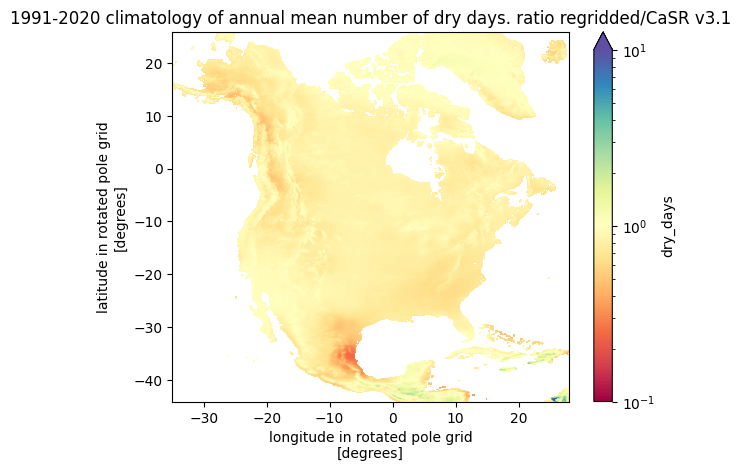

In [2]:

#sim
sim=[]
for r in ['south','middle','north']:
    ds=xr.open_zarr(f"{CONFIG['paths']['tmpdir']}/CMIP6_ScenarioMIP_CSIRO_ACCESS-ESM1-5_ssp585_r1i1p1f1_global+NAM-C3+{r}C3+regridded.zarr")
    ds=xs.utils.unstack_fill_nan(ds, coords=glob.glob(f"{CONFIG['paths']['final']}/coords/*{r}*")[0])
    sim.append(ds)
ds_sim= xr.concat(sim, dim='rlat')
ds_sim=xc.atmos.dry_days(ds_sim.pr, thresh='1 mm/d').sel(time=slice('1991','2020')).mean(dim='time')


# ref
ds_ref=xr.open_zarr(f"{CONFIG['paths']['final']}/reference/NAM-C3_default.zarr.zip")
ds_ref=xc.atmos.dry_days(ds_ref.pr, thresh='1 mm/d').sel(time=slice('1991','2020')).mean(dim='time')

diff=ds_sim/ds_ref

norm = mcolors.LogNorm(vmin=0.1, vmax=10)

diff.plot(norm=norm, cmap='Spectral')
plt.title('1991-2020 climatology of annual mean number of dry days. ratio regridded/CaSR v3.1')

1.8682808716707022


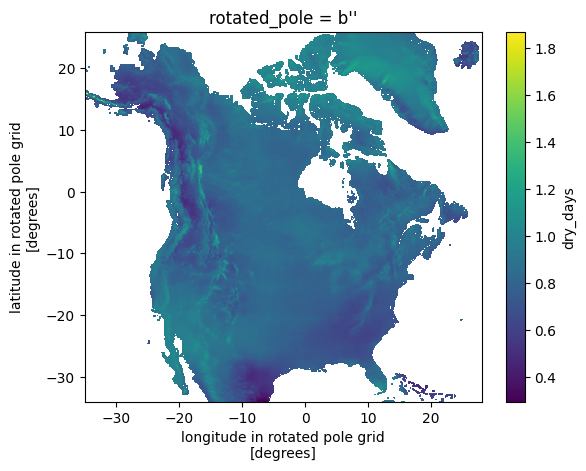

In [15]:
cut=diff.sel(rlat=slice(-34,None))
print(cut.max().values)
cut.plot()

In [16]:
cut.where((cut==1.8682808716707022).compute(), drop=True)

<xarray.DataArray 'dry_days' (rlat: 1, rlon: 1)> Size: 8B
dask.array<where, shape=(1, 1), dtype=float64, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * rlat          (rlat) float32 4B 15.93
  * rlon          (rlon) float32 4B -34.68
    lat           (rlat, rlon) float32 4B 54.77
    lon           (rlat, rlon) float32 4B -163.9
    rotated_pole  |S1 1B b''

2025-09-26 15:00:36 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


/tmp/ipykernel_1460295/3625312593.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


2025-09-26 15:00:36 INFO     xscen.spatial   Loading latitude for more efficient subsetting.
2025-09-26 15:00:37 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/ESPO6e/coords/coords_southC3_235x700.nc.


/tmp/ipykernel_1460295/3625312593.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
/tmp/ipykernel_1460295/3625312593.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


2025-09-26 15:00:37 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/ESPO6e/coords/coords_middleC3_267x700.nc.


/tmp/ipykernel_1460295/3625312593.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
/tmp/ipykernel_1460295/3625312593.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


2025-09-26 15:00:38 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/ESPO6e/coords/coords_northC3_276x700.nc.


/tmp/ipykernel_1460295/3625312593.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
/tmp/ipykernel_1460295/3625312593.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.


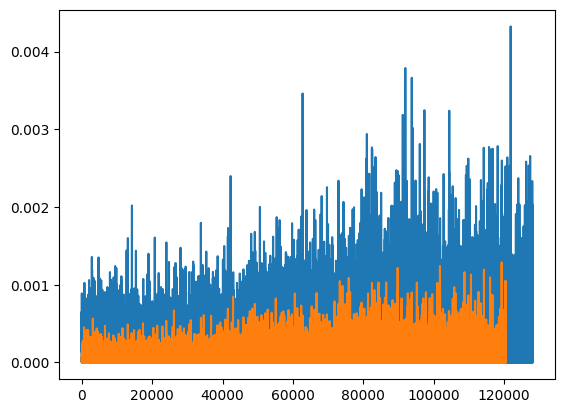

In [19]:
for f in glob.glob(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO6e_v20/CMIP6/ScenarioMIP/NAM-C3/*/ACCESS-ESM1-5/ssp585/*/day/pr/*"):
    ds= xr.open_zarr(f)
    ds=xs.spatial.subset(ds, method='gridpoint',lat=54.770615, lon=-163.9223)
    plt.plot(ds.pr.values)
sim=[]
for r in ['south','middle','north']:
    ds_sim=xr.open_zarr(f"{CONFIG['paths']['tmpdir']}/CMIP6_ScenarioMIP_CSIRO_ACCESS-ESM1-5_ssp585_r1i1p1f1_global+NAM-C3+{r}C3+regridded.zarr")
    ds_sim=xs.utils.unstack_fill_nan(ds_sim, coords=glob.glob(f"{CONFIG['paths']['final']}/coords/*{r}*")[0])
    sim.append(ds_sim)
ds_sim= xr.concat(sim, dim='rlat')
ds_sim=xs.spatial.subset(ds_sim, method='gridpoint',lat=54.770615, lon=-163.9223)
plt.plot(ds_sim.pr.values)

In [18]:
display(ds)
display(ds_sim)

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 128115)
Coordinates:
    lat           float32 4B 54.77
    lon           float32 4B -163.9
    rlat          float32 4B 15.93
    rlon          float32 4B -34.68
    rotated_pole  |S1 1B b''
  * time          (time) object 1MB 1950-01-01 00:00:00 ... 2300-12-31 00:00:00
Data variables:
    pr            (time) float32 512kB dask.array<chunksize=(1460,), meta=np.ndarray>
Attributes: (12/25)
    Notes:                        Regridded on the grid of CaSR v3.1, then bi...
    avertissement:                Ouranos ne donne aucune garantie, expresse ...
    cat:_data_format_:            zarr
    cat:activity:                 ScenarioMIP
    cat:bias_adjust_institution:  Ouranos
    cat:bias_adjust_project:      ESPO6e
    ...                           ...
    disclaimer:                   Ouranos make no warranty, either express or...
    history:                      [2025-09-26 14:57:12] gridpoint spatial sub...
    license:                      Creative Commons Attribution 4.0 Internatio...
    organisation:                 Groupe scénarios et services climatiques, C...
    organization:                 Scenarios and Climate Services Group, Ouran...
    version:                      v20

<xarray.Dataset> Size: 3MB
Dimensions:       (rlat: 3, time: 128115)
Coordinates:
    lat           float32 4B 54.77
    lon           float32 4B -163.9
  * rlat          (rlat) float32 12B 15.93 15.93 15.93
    rlon          float32 4B -34.68
    rotated_pole  |S1 1B b''
  * time          (time) object 1MB 1950-01-01 00:00:00 ... 2300-12-31 00:00:00
Data variables:
    pr            (rlat, time) float32 2MB dask.array<chunksize=(1, 1460), meta=np.ndarray>
Attributes: (12/25)
    Notes:                        Regridded on the grid of CaSR v3.1, then bi...
    avertissement:                Ouranos ne donne aucune garantie, expresse ...
    cat:_data_format_:            zarr
    cat:activity:                 ScenarioMIP
    cat:bias_adjust_institution:  Ouranos
    cat:bias_adjust_project:      ESPO6e
    ...                           ...
    disclaimer:                   Ouranos make no warranty, either express or...
    history:                      [2025-09-26 14:58:13] gridpoint spatial sub...
    license:                      Creative Commons Attribution 4.0 Internatio...
    organisation:                 Groupe scénarios et services climatiques, C...
    organization:                 Scenarios and Climate Services Group, Ouran...
    version:                      v20

In [5]:

xs.spatial.subset(diff, method='gridpoint',lat=11.31, lon=-73.77).values

array(2.8053553)